### Case Study 1: Imports and Libraries Setup
- **Objective**: Sentiment Analysis task ke liye zaroori standard aur machine learning libraries ko import karna.
- **Key Libraries**:
  - `pandas` aur `numpy` data manipulation ke liye.
  - `matplotlib` aur `seaborn` visualizations ke liye.
  - `sklearn` data split karne, TF-IDF vectorization aur evaluation metrics ke liye.

In [1]:
import numpy as np
import pandas as pd
import re
import string
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("niraliivaghani/flipkart-product-customer-reviews-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flipkart-product-customer-reviews-dataset' dataset.
Path to dataset files: /kaggle/input/flipkart-product-customer-reviews-dataset


### Case Study 2: Dataset Download
- **Objective**: Kaggle API (`kagglehub`) ka use karke Flipkart Product Customer Reviews dataset ko direct download karna.

In [3]:
import os
import pandas as pd

file_path = os.path.join(
    path,
    "Dataset-SA.csv"
)

df = pd.read_csv(file_path)

df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


### Case Study 3: Data Loading & Initial Inspection
- **Objective**: Downloaded path se `Dataset-SA.csv` file ko read karna aur starting rows (`df.head()`) ko dekh kar columns aur data format ka andaza lagana.

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (205052, 6)


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


### Case Study 4: Checking Shape & Missing Values
- **Objective**: Dataset ki total rows aur columns check karna aur identify karna ki kaunse columns (jaise `Review` aur `Summary`) mein null values hain.

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64


In [8]:
for col in df.columns:

    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

print("Null values after filling:")
print(df.isnull().sum())

Null values after filling:
product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64


### Case Study 5: Missing Value Treatment
- **Objective**: Null values ko treat karna. Object/text columns mein null values ko 'Unknown' ya blank space se fill karna taaki downstream text processing mein error na aaye.

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 34375


In [10]:
print(df["Sentiment"].value_counts())

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


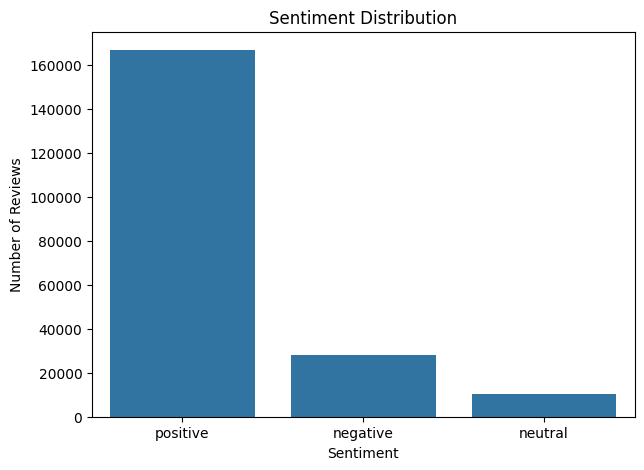

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [12]:
# Separate classes
positive_data = df[df["Sentiment"] == "positive"]
negative_data = df[df["Sentiment"] == "negative"]
neutral_data = df[df["Sentiment"] == "neutral"]

# Positive class ko reduce karo
positive_data = positive_data.sample(
    n=40000,
    random_state=42
)

# Combine all classes
df = pd.concat(
    [
        positive_data,
        negative_data,
        neutral_data
    ],
    ignore_index=True
)

# Shuffle
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Check distribution
print("After Balancing:")
print(df["Sentiment"].value_counts())

print("\nPercentage:")
print(
    df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

After Balancing:
Sentiment
positive    40000
negative    28232
neutral     10239
Name: count, dtype: int64

Percentage:
Sentiment
positive    50.97
negative    35.98
neutral     13.05
Name: proportion, dtype: float64


### Case Study 6: Class Imbalance Treatment (Undersampling)
- **Objective**: Dataset mein positive reviews bahut zyada the (1.6L+). Model ko unbiased banane ke liye positive class ko reduce karke data ko balance kiya gaya.

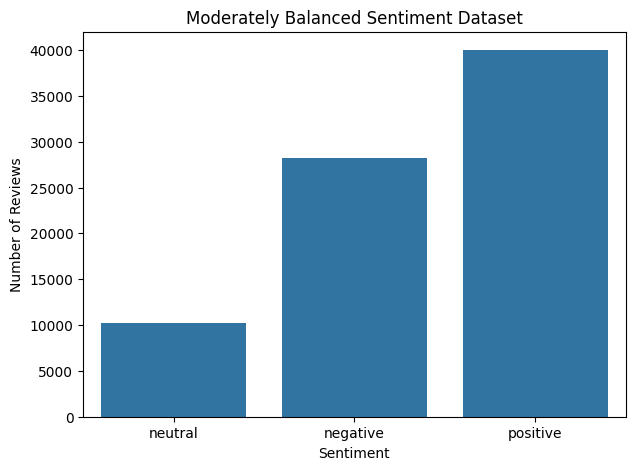

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Moderately Balanced Sentiment Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

/tmp/ipykernel_6262/784233900.py:25: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6262/784233900.py:25: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6262/784233900.py:25: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6262/784233900.py:25: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

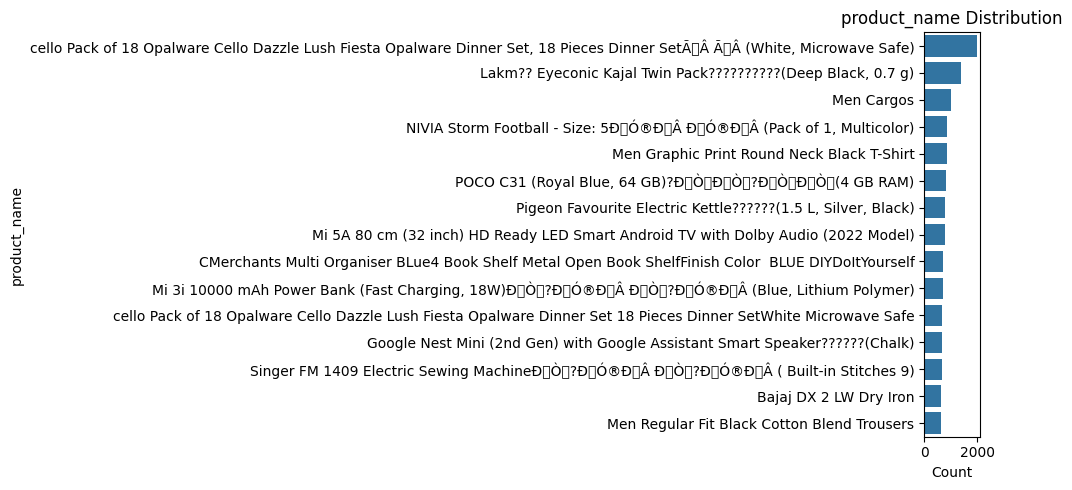

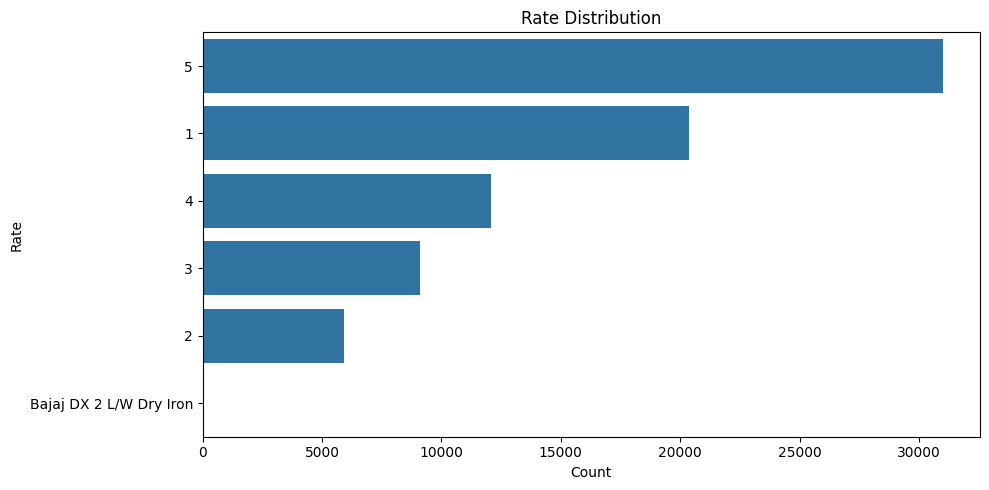

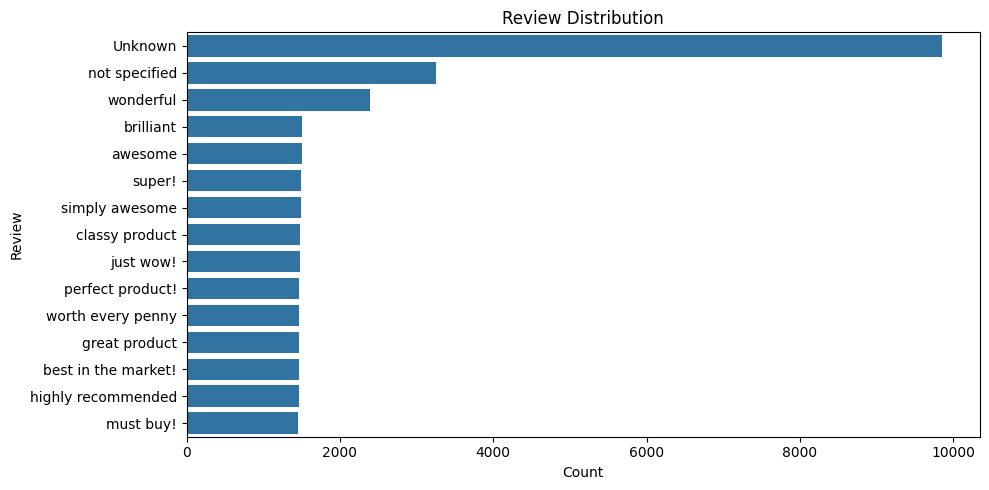

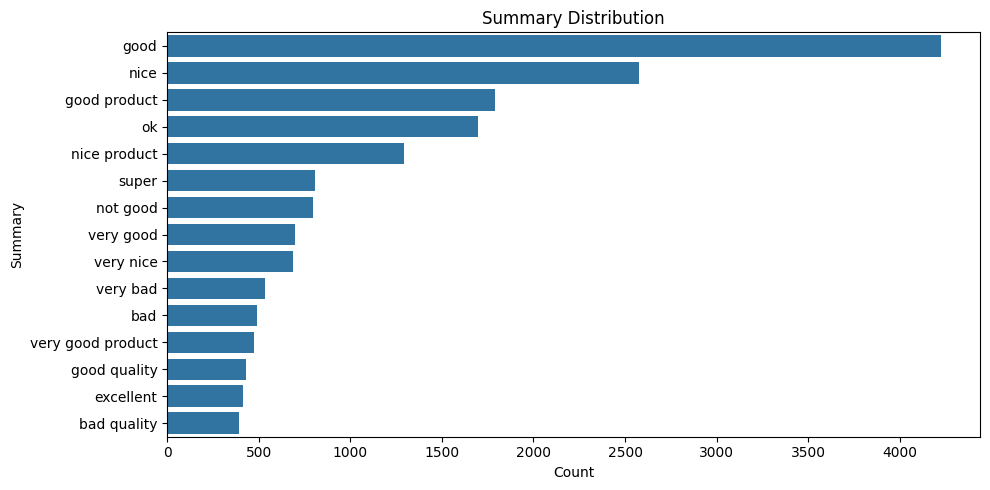

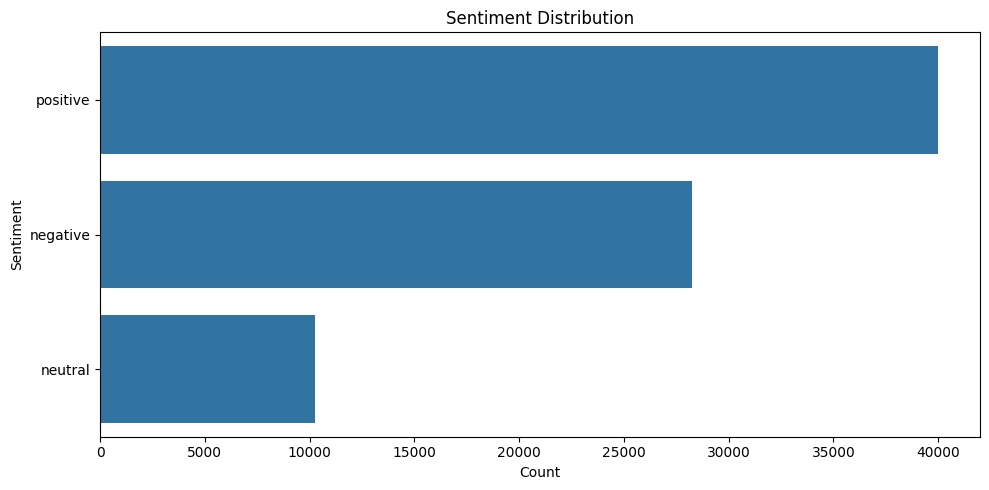

In [14]:
categorical_columns = [
    "product_name",
    "Rate",
    "Review",
    "Summary",
    "Sentiment"
]

for col in categorical_columns:

    plt.figure(figsize=(10, 5))

    # Sirf top 15 categories dikhayenge
    top_values = df[col].value_counts().head(15)

    sns.barplot(
        x=top_values.values,
        y=top_values.index
    )

    plt.title(f"{col} Distribution")
    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

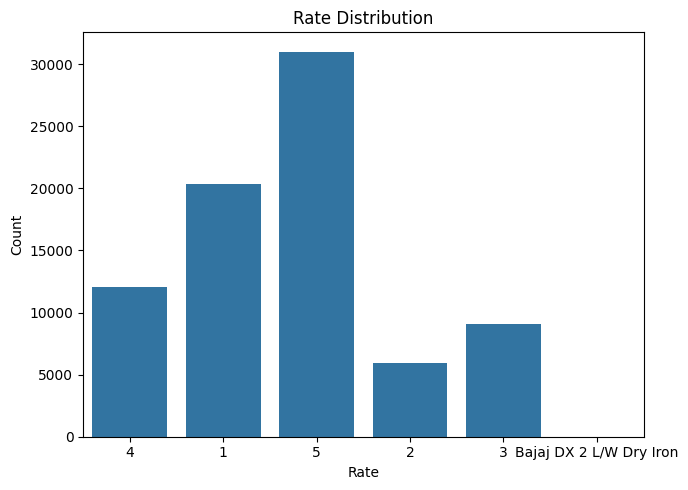

In [27]:
for col in ["Rate"]:
    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

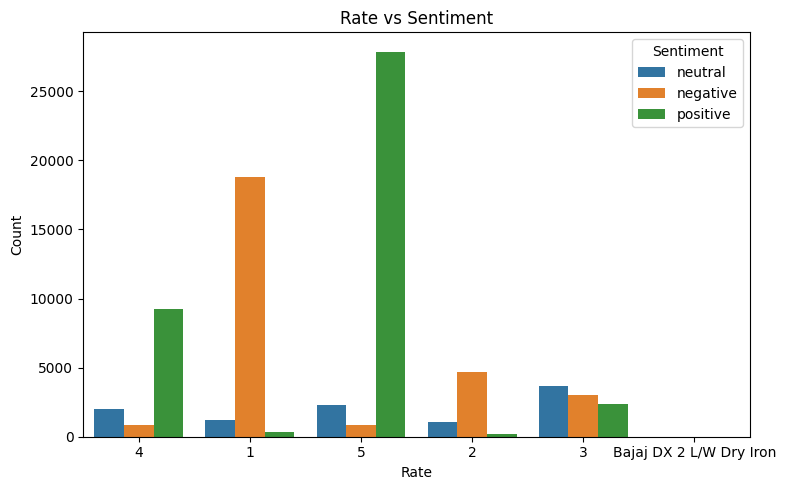

In [28]:
for col in ["Rate"]:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col,
        hue="Sentiment"
    )

    plt.title(f"{col} vs Sentiment")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

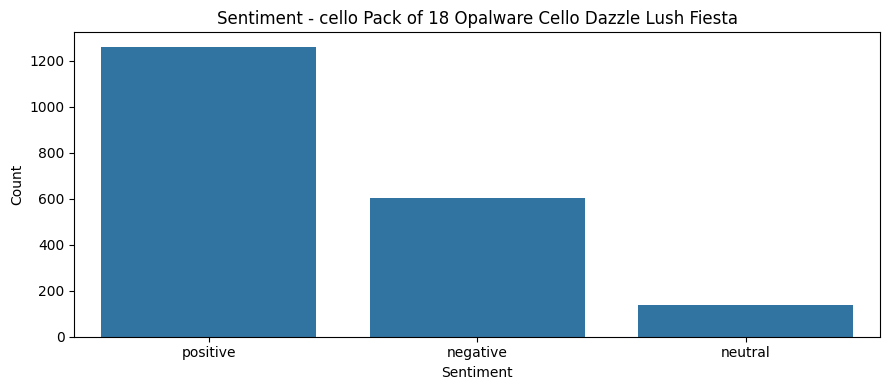

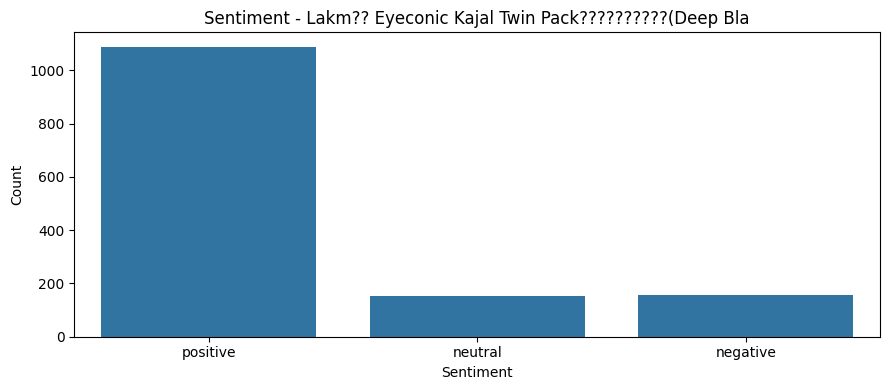

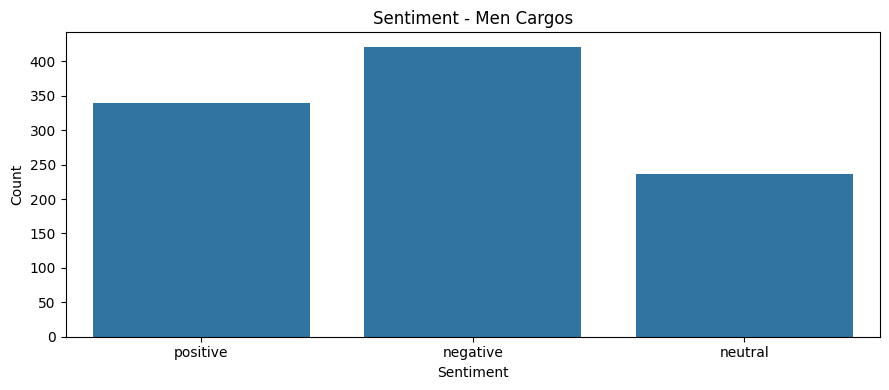

/tmp/ipykernel_6262/739841879.py:17: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6262/739841879.py:17: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


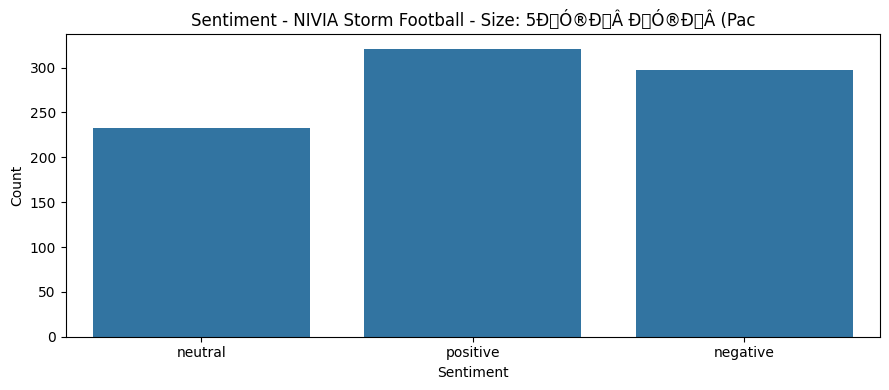

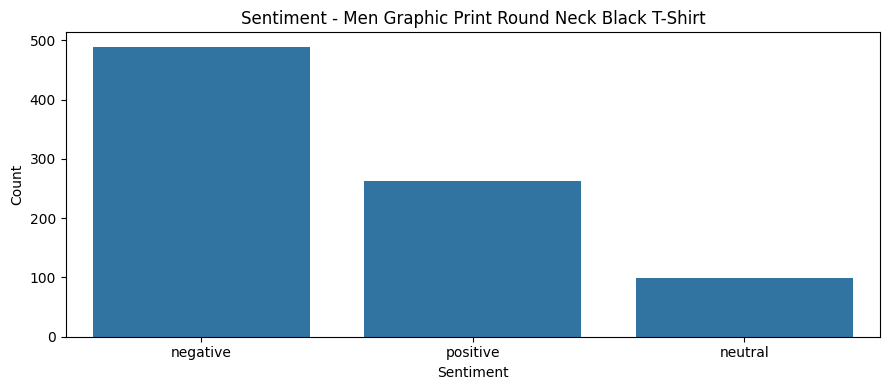

/tmp/ipykernel_6262/739841879.py:17: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6262/739841879.py:17: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6262/739841879.py:17: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


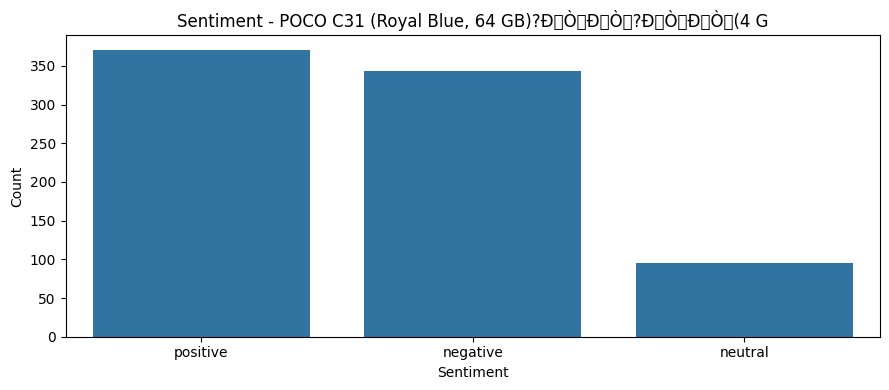

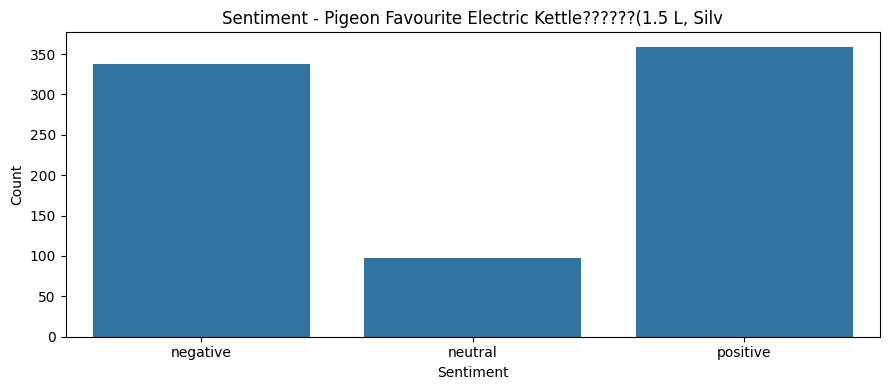

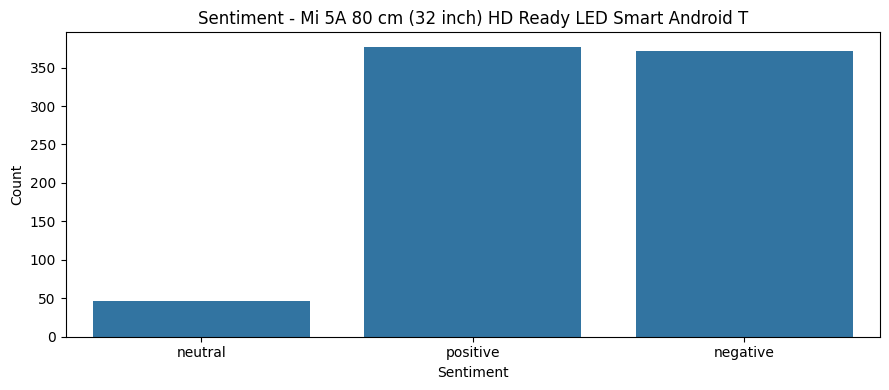

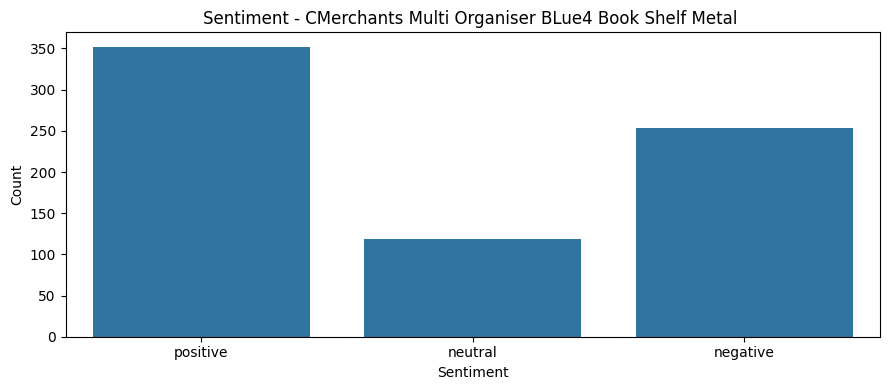

/tmp/ipykernel_6262/739841879.py:17: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


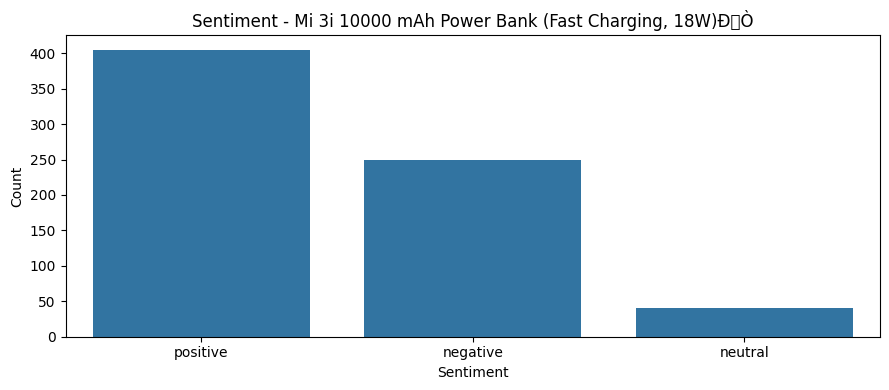

In [29]:
top_products = df["product_name"].value_counts().head(10).index

for product in top_products:
    temp = df[df["product_name"] == product]

    plt.figure(figsize=(9, 4))

    sns.countplot(
        data=temp,
        x="Sentiment"
    )

    plt.title(f"Sentiment - {product[:50]}")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

In [15]:
df["Review"] = df["Review"].fillna("")
df["Summary"] = df["Summary"].fillna("")

print("Review missing:", df["Review"].isnull().sum())
print("Summary missing:", df["Summary"].isnull().sum())

Review missing: 0
Summary missing: 0


In [16]:
df["combined_text"] = (
    df["Review"].astype(str)
    + " "
    + df["Summary"].astype(str)
)

df[["Review", "Summary", "combined_text"]].head()

,Review,Summary,combined_text
0,pretty good,its really amazing but only problem is that it...,pretty good its really amazing but only proble...
1,very poor,low quality,very poor low quality
2,not specified,osm product and fabric is soft,not specified osm product and fabric is soft
3,expected a better product,verry bad product wast of money,expected a better product verry bad product wa...
4,terrific,works perfectly thank you,terrific works perfectly thank you


### Case Study 7: Feature Engineering (Combined Text)
- **Objective**: `Review` aur `Summary` dono text columns ko merge karke ek single text feature (`combined_text`) banana taaki classifier ko poori information ek sath mile.

In [17]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    # Remove HTML
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Keep only alphabets
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

### Case Study 8: Text Cleaning Function
- **Objective**: Raw text ko clean karna. Isme URLs, HTML tags aur special characters/numbers ko hatakar sirf alphabets ko lowercase mein convert kiya gaya.

In [18]:
df["clean_text"] = df["combined_text"].apply(
    clean_text
)

df[
    ["combined_text", "clean_text"]
].head()

,combined_text,clean_text
0,pretty good its really amazing but only proble...,pretty good its really amazing but only proble...
1,very poor low quality,very poor low quality
2,not specified osm product and fabric is soft,not specified osm product and fabric is soft
3,expected a better product verry bad product wa...,expected a better product verry bad product wa...
4,terrific works perfectly thank you,terrific works perfectly thank you


In [19]:
X = df["clean_text"]
y = df["Sentiment"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Classes:")
print(y.value_counts())

X Shape: (78471,)
y Shape: (78471,)

Target Classes:
Sentiment
positive    40000
negative    28232
neutral     10239
Name: count, dtype: int64


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (62776,)
Testing: (15695,)


### Case Study 9: Train-Test Split
- **Objective**: Balanced dataset ko 80% Training aur 20% Testing sets mein split karna taaki model generalized evaluation ke liye ready ho sake.

In [21]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF:", X_train_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Train TF-IDF: (62776, 30000)
Test TF-IDF: (15695, 30000)


### Case Study 10: TF-IDF Vectorization
- **Objective**: Cleaned text data ko numeric representations (features) mein convert karna using TF-IDF (Term Frequency-Inverse Document Frequency) with unigram and bigrams.

In [22]:
svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)

print(
    "SVM Accuracy:",
    round(
        accuracy_score(
            y_test,
            svm_pred
        ) * 100,
        2
    ),
    "%"
)

SVM Accuracy: 89.34 %


### Case Study 11: Linear Support Vector Classifier (LinearSVC) Training
- **Objective**: Model ko train karna. SVM high-dimensional text classifications ke liye highly effective hota hai. Isne ~89.34% accuracy achieve ki.

In [23]:
print(
    classification_report(
        y_test,
        svm_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.90      0.92      0.91      5647
     neutral       0.67      0.64      0.65      2048
    positive       0.94      0.94      0.94      8000

    accuracy                           0.89     15695
   macro avg       0.84      0.83      0.83     15695
weighted avg       0.89      0.89      0.89     15695



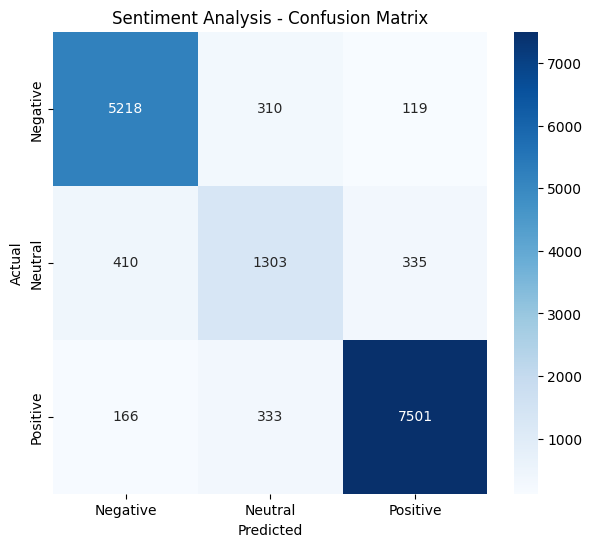

In [24]:

cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Analysis - Confusion Matrix")

plt.show()

### Case Study 12: Confusion Matrix & ROC Curve Evaluation
- **Objective**: Model ke classification performance ko detail mein evaluate karna (Precision, Recall, F1-Score, Confusion Matrix aur Multiclass ROC Curve).

ROC-AUC Score: 0.9549
ROC-AUC (%): 95.49 %


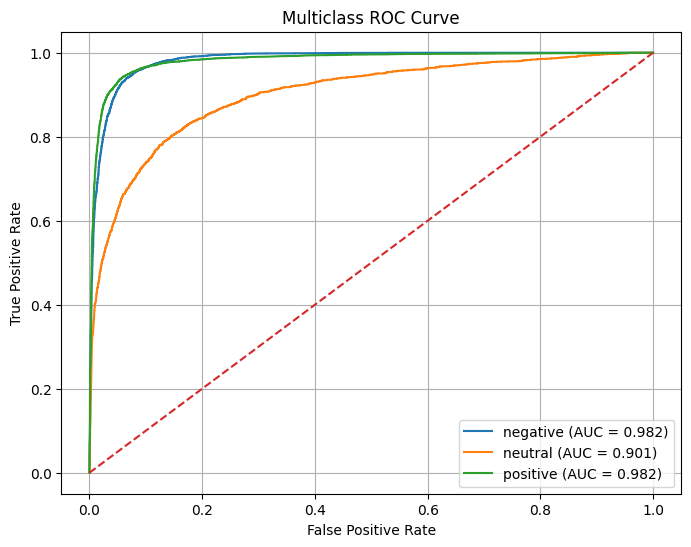

In [25]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Predictions scores
y_score = svm_model.decision_function(X_test_tfidf)

# Classes
classes = svm_model.classes_

# Convert labels to binary format
y_test_bin = label_binarize(
    y_test,
    classes=classes
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test_bin,
    y_score,
    multi_class="ovr",
    average="macro"
)

print("ROC-AUC Score:", round(roc_auc, 4))
print("ROC-AUC (%):", round(roc_auc * 100, 2), "%")


# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc_class = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc_class:.3f})"
    )


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [31]:
import joblib

# Save trained model
joblib.dump(
    svm_model,
    "flipkart_sentiment_svm.joblib"
)

# Save TF-IDF
joblib.dump(
    tfidf,
    "flipkart_sentiment_tfidf.joblib"
)

print("✅ SVM Model saved!")
print("✅ TF-IDF Vectorizer saved!")

✅ SVM Model saved!
✅ TF-IDF Vectorizer saved!


### Case Study 13: Model Serialization (Saving Model)
- **Objective**: Future inferences ya production deployment ke liye trained SVM model aur TF-IDF vectorizer ko `.joblib` files ke roop mein save karna.

In [32]:
import joblib
import re

svm_model = joblib.load(
    "flipkart_sentiment_svm.joblib"
)

tfidf = joblib.load(
    "flipkart_sentiment_tfidf.joblib"
)

print("✅ Model and TF-IDF loaded!")

✅ Model and TF-IDF loaded!


In [33]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    # Remove HTML
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Keep alphabets only
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [37]:
review = input("Enter your Flipkart Review: ")

review_clean = clean_text(review)

review_tfidf = tfidf.transform(
    [review_clean]
)

prediction = svm_model.predict(
    review_tfidf
)[0]

if prediction == "positive":
    print("\n😊 POSITIVE REVIEW")

elif prediction == "negative":
    print("\n😡 NEGATIVE REVIEW")

else:
    print("\n😐 NEUTRAL REVIEW")

Enter your Flipkart Review: this product is not valuable , but  i like it 

😡 NEGATIVE REVIEW


### Case Study 14: Interactive Sentiment Prediction
- **Objective**: Ek realtime prediction system banana jisme user apna review input karke instantly check kar sake ki review Positive, Negative, ya Neutral hai.